In [1]:
%pip install -q transformers pillow matplotlib pandas requests

In [ ]:
import io
import json
import random
import zipfile
from pathlib import Path

import requests
import torch
import torch.nn.functional as F
import transformers
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, CLIPModel
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

In [3]:
ROOT = Path.cwd()

DATA = ROOT / "data"
IMAGES = DATA / "images"
OUTPUTS = ROOT / "outputs"

for folder in (DATA, IMAGES, OUTPUTS):
    folder.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Folder:", ROOT)
print("Device:", device)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

Folder: /content
Device: cuda
PyTorch: 2.11.0+cu130
Transformers: 5.18.0


In [4]:
manifest_path = DATA / "xm3600_subset500.json"

if not manifest_path.exists():
    url = "https://google.github.io/crossmodal-3600/web-data/captions.zip"

    response = requests.get(url, timeout=60)
    response.raise_for_status()

    eligible = []

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        with archive.open("captions.jsonl") as source:
            for line in source:
                item = json.loads(line)

                en = item.get("en", {}).get("caption", [])
                bn = item.get("bn", {}).get("caption", [])

                if en and bn:
                    eligible.append({
                        "image_id": item["image/key"],
                        "en": en,
                        "bn": bn,
                    })

    eligible.sort(key=lambda item: item["image_id"])
    subset = random.Random(42).sample(eligible, 500)

    manifest_path.write_text(
        json.dumps(subset, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

subset = json.loads(manifest_path.read_text(encoding="utf-8"))
print("Fixed image count:", len(subset))

Fixed image count: 500


In [5]:
demo = subset[:3]
image_ids = [item["image_id"] for item in demo]
captions = [item["en"][0] for item in demo]

images = []

for image_id in image_ids:
    path = IMAGES / f"{image_id}.jpg"

    if not path.exists():
        url = (
            "https://open-images-dataset.s3.amazonaws.com/"
            f"crossmodal-3600/{image_id}.jpg"
        )
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)

    with Image.open(path) as image:
        images.append(image.convert("RGB"))

I0 / T0: An aerial view of two cities divided by a river.
I1 / T1: The food item in the plate.
I2 / T2: A portrait view of a yellow flower in the grass.


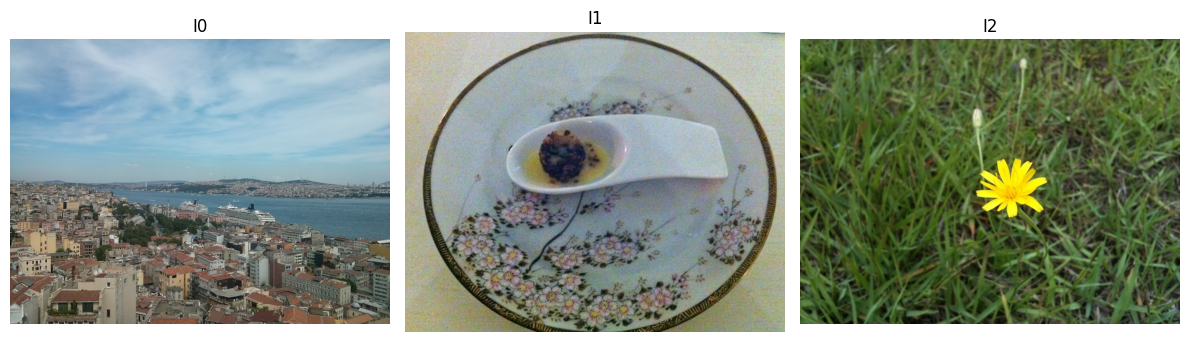

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (axis, image, caption) in enumerate(zip(axes, images, captions)):
    axis.imshow(image)
    axis.set_title(f"I{i}")
    axis.axis("off")
    print(f"I{i} / T{i}: {caption}")

plt.tight_layout()
plt.show()

**Model and embeddings**

In [7]:
MODEL_ID = "openai/clip-vit-base-patch16"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

In [8]:
batch = processor(
    images=images,
    text=captions,
    padding=True,
    truncation=True,
    max_length=77,
    return_tensors="pt"
).to(device)

with torch.inference_mode():
    outputs = model(**batch)

In [9]:
image_embeddings = outputs.image_embeds.float().cpu()
text_embeddings = outputs.text_embeds.float().cpu()

print("Image embeddings:", image_embeddings.shape)
print("Text embeddings:", text_embeddings.shape)
print("Image vector lengths:", image_embeddings.norm(dim=-1))
print("Text vector lengths:", text_embeddings.norm(dim=-1))

Image embeddings: torch.Size([3, 512])
Text embeddings: torch.Size([3, 512])
Image vector lengths: tensor([1.0000, 1.0000, 1.0000])
Text vector lengths: tensor([1.0000, 1.0000, 1.0000])


In [10]:
example = torch.tensor([[3.0, 4.0]])
print("Normalized [3, 4]:", F.normalize(example, dim=-1))

Normalized [3, 4]: tensor([[0.6000, 0.8000]])


**Similarity matrix**

In [11]:
similarity = image_embeddings @ text_embeddings.T

similarity_df = pd.DataFrame(
    similarity.numpy(),
    index=["I0", "I1", "I2"],
    columns=["T0", "T1", "T2"],
)

display(similarity_df.round(3))

for i in range(3):
    best_j = similarity[i].argmax().item()
    print(f"I{i} → T{best_j}: {captions[best_j]}")

,T0,T1,T2
I0,0.217,0.175,0.144
I1,0.114,0.294,0.154
I2,0.112,0.195,0.322


I0 → T0: An aerial view of two cities divided by a river.
I1 → T1: The food item in the plate.
I2 → T2: A portrait view of a yellow flower in the grass.


**Contrastive learning and temperature**

In [12]:
def symmetric_loss(scores, temperature):
    logits = scores / temperature
    targets = torch.arange(scores.shape[0])
    
    image_to_text = F.cross_entropy(logits, targets)
    text_to_image = F.cross_entropy(logits.T, targets)
    
    return (image_to_text + text_to_image) / 2

In [14]:
toy_similarity = torch.tensor([
    [0.8, 0.2],
    [0.1, 0.7]
])

for temperature in (1.0, 0.1):
    correct = symmetric_loss(toy_similarity, temperature)
    
    wrong = symmetric_loss(
        toy_similarity[:, [1, 0]],
        temperature
    )
    
    print(
        f"\nTemperature={temperature}: "
        f"correct loss={correct.item():.4f}, "
        f"wrong loss={wrong.item():.4f}"
    )

    print("Row probabilities:")
    print((toy_similarity / temperature).softmax(dim=-1))


Temperature=1.0: correct loss=0.4381, wrong loss=1.0381
Row probabilities:
tensor([[0.6457, 0.3543],
        [0.3543, 0.6457]])

Temperature=0.1: correct loss=0.0031, wrong loss=6.0031
Row probabilities:
tensor([[0.9975, 0.0025],
        [0.0025, 0.9975]])


**Prediction using fixed class prompts**

In [15]:
labels = ["a city", "food", "a flower", "a dog", "a car"]
prompts = [f"a photo of {label}." for label in labels]

batch = processor(
    images=images,
    text=prompts,
    padding=True,
    truncation=True,
    max_length=77,
    return_tensors="pt"
).to(device)

In [16]:
with torch.inference_mode():
    zero_outputs = model(**batch)

logits = zero_outputs.logits_per_image.float().cpu()
relative_scores = logits.softmax(dim=-1)

zero_shot_df = pd.DataFrame(
    relative_scores.numpy(),
    index=["I0", "I1", "I2"],
    columns=labels
)

display(zero_shot_df.round(3))

,a city,food,a flower,a dog,a car
I0,0.995,0.001,0.001,0.000,0.003
I1,0.000,0.877,0.120,0.001,0.002
I2,0.000,0.000,0.997,0.002,0.001


In [17]:
for i in range(3):
    predicted = relative_scores[i].argmax().item()
    print(
        f"I{i}: {labels[predicted]} "
        f"| relative score={relative_scores[i, predicted]:.3f}"
    )

I0: a city | relative score=0.995
I1: food | relative score=0.877
I2: a flower | relative score=0.997


In [18]:
keep = [i for i, label in enumerate(labels) if label != "a flower"]

reduced_scores = logits[2, keep].softmax(dim=-1)
best = reduced_scores.argmax().item()

print("Flower image, with flower class removed:")
print("Prediction:", labels[keep[best]])
print("Relative score:", reduced_scores[best].item())

Flower image, with flower class removed:
Prediction: a dog
Relative score: 0.5493302345275879


In [19]:
torch.save(
    {
        "model_id": MODEL_ID,
        "torch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        "image_ids": image_ids,
        "captions": captions,
        "image_embeddings": image_embeddings,
        "text_embeddings": text_embeddings,
    },
    OUTPUTS / "day1_clip_demo_embeddings.pt"
)

similarity_df.to_csv(OUTPUTS / "day1_similarity.csv")
zero_shot_df.to_csv(OUTPUTS / "day1_zero_shot_scores.csv")

print("Saved to:", OUTPUTS)

Saved to: /content/outputs


**Queries IDs**

In [ ]:
subset = json.loads(manifest_path.read_text(encoding="utf-8"))

eval_image_ids = [item["image_id"] for item in subset]

caption_records = [
    {
        "image_id": item["image_id"],
        "caption_index": j,
        "text": caption,
    }
    for item in subset
    for j, caption in enumerate(item["en"])
]

texts = [record["text"] for record in caption_records]
text_image_ids = [record["image_id"] for record in caption_records]

assert len(eval_image_ids) == 500
assert len(set(eval_image_ids)) == 500

print("Images:", len(eval_image_ids))
print("English captions:", len(texts))